In [1]:
%display latex
forget()

In [2]:
heartline = 0.155

In [3]:
# Calculating Second Derivative of Frequency

def impulse(acc, dur):
    return acc*unit_step(x)-2*acc*unit_step(x-dur)+acc*unit_step(x-2*dur) 

there_and_back = [(1, 2), (-2, 2), (1, 2)]
spin = [(2, 1), (0, 2), (-2, 1)]
swing = [(2 * i, v/2) for i, v in [(1, 1), (-1, 1), (-2, 1), (2, 1), (1, 1), (-1, 1)]]
params = swing + [(-1 * i, 1 * v) for i, v in spin] + there_and_back + spin + [(-1 * i, v) for i,v in there_and_back] + swing

end_time = sum(2*j for i, j in params)

offset = 0
frequency_dotdot = 0
for a, d in params:
    frequency_dotdot += impulse(a/3, d).subs(x == x - offset)
    offset += 2*d

In [4]:
# Calculating Derivative of Frequency

frequency_dot = integral(frequency_dotdot, x, 0, x)

In [5]:
# Calculating Frequency

frequency = integral(frequency_dot, x, 0, x)

In [6]:
# Creating the theta function

assume(x>0)
theta = integrate(2 * pi * frequency, x, 0, x)

In [7]:
# Acceleration WRT riders

r = var('r')   # Rider to center of rotation
g = 9.81       # Gravity

ac = (2 * pi * frequency) ^ 2 * r
at = 2 * pi * frequency_dot * r


# Radial Acceleration WRT rider - Azg
azg_lower = ac - g * cos(theta - pi/2)
azg_upper = ac + g * cos(theta + pi/2)

# Angular Acceration WRT rider - Ayg
ayg_lower = at - g * sin(theta - pi/2)
ayg_upper = at + g * sin(theta + pi/2)

In [8]:
# Creating the gravity eggs

e = var('e');
yzQ12 = sqrt((1-(e^2/3^2))*6^2)
yzQ34 = -1*sqrt((1-(e^2/3^2))*2^2)

# X-Y Egg
xyQ1 = sqrt((1-(e^2/6^2))*3^2)
xyQ2 = sqrt((1-(e^2/2^2))*3^2)
xyQ3 = -1*xyQ2
xyQ4 = -1*xyQ1

# X-Z Egg
xzQ1 = sqrt((1-(e^2/6^2))*6^2)
xzQ2 = sqrt((1-(e^2/2^2))*6^2)
xzQ3 = -1*sqrt((1-(e^2/2^2))*2^2)
xzQ4 = -1*sqrt((1-(e^2/6^2))*2^2)

yzegg = plot(yzQ12, [-3, 3], rgbcolor = "red") + plot(yzQ34, [-3, 3], rgbcolor = "red")
xyegg = plot(xyQ1, [0, 6], rgbcolor = "red") + plot(xyQ2, [-2, 0], rgbcolor = "red") + plot(xyQ3, [-2, 0], rgbcolor = "red") + plot(xyQ4, [0, 6], rgbcolor = "red")
xzegg = plot(xzQ1, [0, 6], rgbcolor = "red") + plot(xzQ2, [-2, 0], rgbcolor = "red") + plot(xzQ3, [-2, 0], rgbcolor = "red") + plot(xzQ4, [0, 6], rgbcolor = "red")

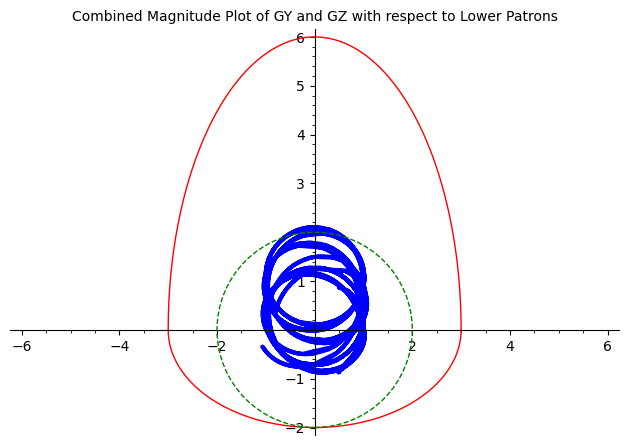

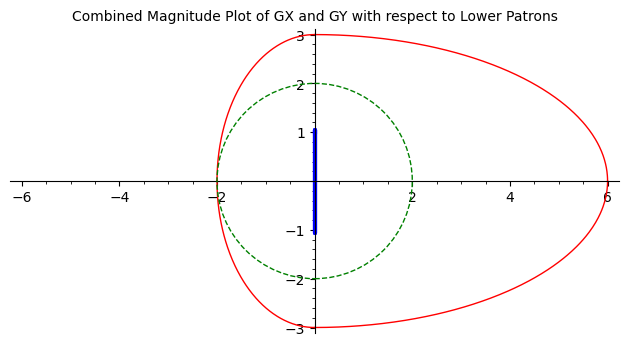

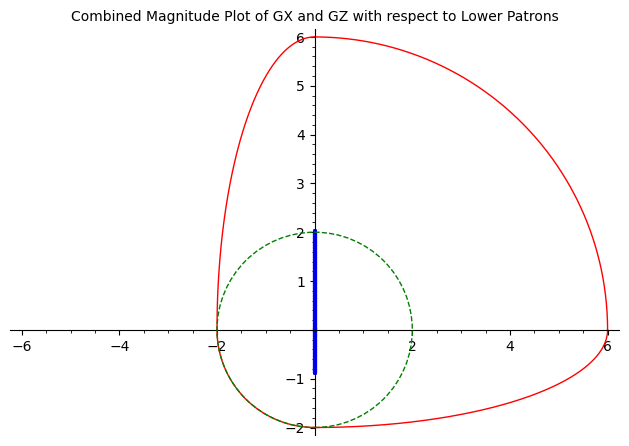

In [9]:
# Gravity Eggs WRT Lower Riders

gyzegg_lower = parametric_plot((ayg_lower.subs(r==heartline) / g, azg_lower.subs(r==heartline) / g), (x, 0, end_time), thickness = 3)
show(gyzegg_lower + yzegg + circle((0,0), 2, linestyle = "dashed", rgbcolor = "green"), title="Combined Magnitude Plot of GY and GZ with respect to Lower Patrons", aspect_ratio=1, xmin=-6, xmax=6)
gxyegg_lower = parametric_plot((0, ayg_lower.subs(r==heartline) / g), (x, 0, end_time), thickness = 3)
show(gxyegg_lower + xyegg + circle((0,0), 2, linestyle = "dashed", rgbcolor = "green"), title="Combined Magnitude Plot of GX and GY with respect to Lower Patrons", aspect_ratio=1, xmin=-6, xmax=6)
gxzegg_lower = parametric_plot((0, azg_lower.subs(r==heartline) / g), (x, 0, end_time), thickness = 3)
show(gxzegg_lower + xzegg + circle((0,0), 2, linestyle = "dashed", rgbcolor = "green"), title="Combined Magnitude Plot of GX and GZ with respect to Lower Patrons", aspect_ratio=1, xmin=-6, xmax=6)

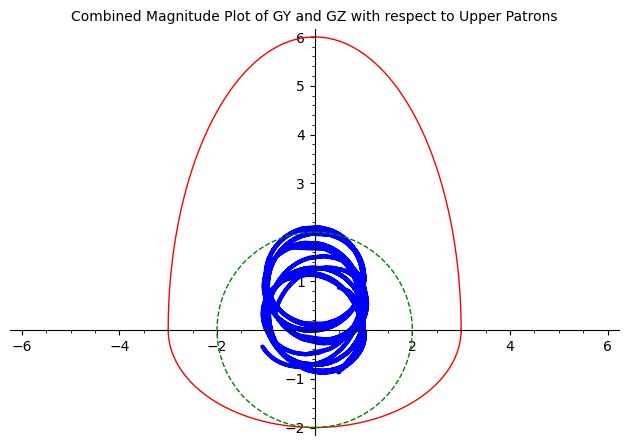

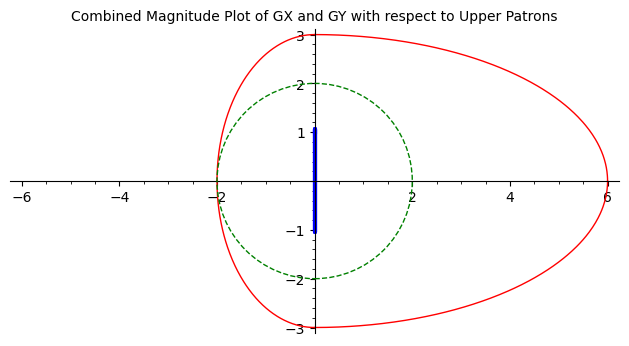

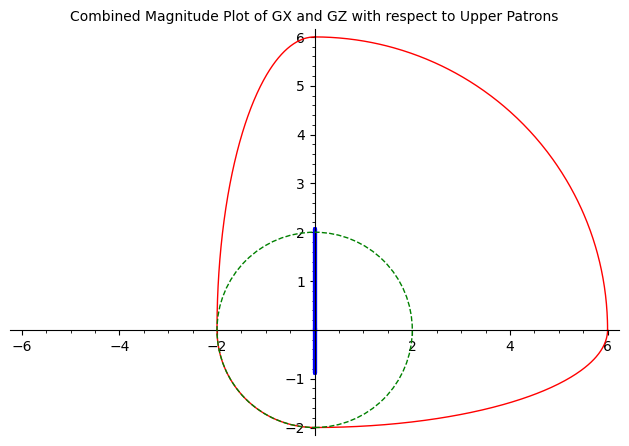

In [10]:
# Gravity Eggs WRT Upper Riders

gyzegg_upper = parametric_plot((ayg_upper.subs(r==heartline) / g, azg_upper.subs(r==heartline) / g), (x, 0, end_time), thickness = 3)
show(gyzegg_upper + yzegg + circle((0,0), 2, linestyle = "dashed", rgbcolor = "green"), title="Combined Magnitude Plot of GY and GZ with respect to Upper Patrons", aspect_ratio=1, xmin=-6, xmax=6)
gxyegg_upper = parametric_plot((0, ayg_upper.subs(r==heartline) / g), (x, 0, end_time), thickness = 3)
show(gxyegg_upper + xyegg + circle((0,0), 2, linestyle = "dashed", rgbcolor = "green"), title="Combined Magnitude Plot of GX and GY with respect to Upper Patrons", aspect_ratio=1, xmin=-6, xmax=6)
gxzegg_upper = parametric_plot((0, azg_upper.subs(r==heartline) / g), (x, 0, end_time), thickness = 3)
show(gxzegg_upper + xzegg + circle((0,0), 2, linestyle = "dashed", rgbcolor = "green"), title="Combined Magnitude Plot of GX and GZ with respect to Upper Patrons", aspect_ratio=1, xmin=-6, xmax=6)

In [11]:
# Acceleration tables
end_time = sum(2*j for i, j in params)
delta = 0.01^(-1)
yacc_lower = []
yacc_upper = []
zacc_lower = []
zacc_upper = []
for dt in range(0, int(delta*end_time)):
    yacc_lower.append((dt/delta, n(ayg_lower.subs(r==heartline, x==dt/delta), 100)/g))
    yacc_upper.append((dt/delta, n(ayg_upper.subs(r==heartline, x==dt/delta), 100)/g))
    zacc_lower.append((dt/delta, n(azg_lower.subs(r==heartline, x==dt/delta), 100)/g))
    zacc_upper.append((dt/delta, n(azg_upper.subs(r==heartline, x==dt/delta), 100)/g))

ytable_lower = []
ytable_upper = []
ztable_lower = []
ztable_upper = []
for height in range(int(6*100), int(-3*100)+1, int(-0.01*100)):
    for accel, tab in [(yacc_lower, ytable_lower), (yacc_upper, ytable_upper), (zacc_lower, ztable_lower), (zacc_upper, ztable_upper)]:
        count = 0
        for _, acc in accel:
            if acc >= height/10:
                count += delta^(-1)
            elif count != 0:
                tab.append((n(height/10), count))
                count = 0
            else:
                count = 0
        if count != 0:
            tab.append((n(height/10), count))

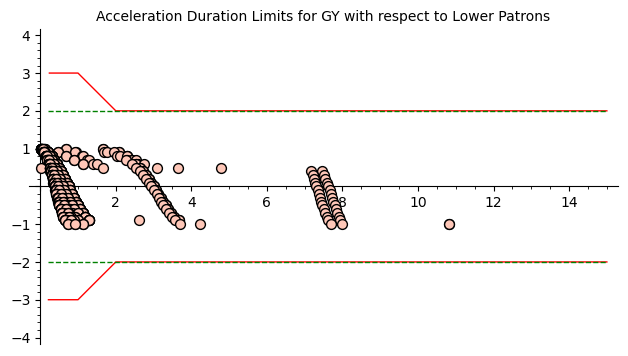

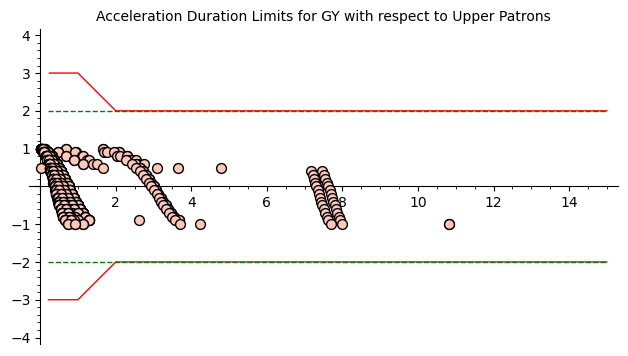

In [14]:
topGy = piecewise([([0.2,1], 3), ((1,2), 4-x), ([2,15], 2)]);
bottomGy = -1*topGy;
REC_Req = 2;
yLims = plot(topGy, [0, 15], rgbcolor = "red") + plot(bottomGy, [0,15], rgbcolor = "red") + plot(REC_Req, [0.2,15], linestyle = "dashed", rgbcolor = "green") + plot(-REC_Req, [0.2,15], linestyle = "dashed", rgbcolor = "green");

ydots_lower = scatter_plot([(time, acc) for acc, time in ytable_lower])
show(yLims + ydots_lower, title="Acceleration Duration Limits for GY with respect to Lower Patrons", aspect_ratio = '1', xmin=0, xmax=15, ymin=-4, ymax=4)

ydots_upper = scatter_plot([(time, acc) for acc, time in ytable_upper])
show(yLims + ydots_upper, title="Acceleration Duration Limits for GY with respect to Upper Patrons", aspect_ratio = '1', xmin=0, xmax=15, ymin=-4, ymax=4)

verbose 0 (3987: plot.py, generate_plot_points) WARNING: When plotting, failed to evaluate function at 15 points.
verbose 0 (3987: plot.py, generate_plot_points) Last error message: 'Unable to compute f(3.0)'


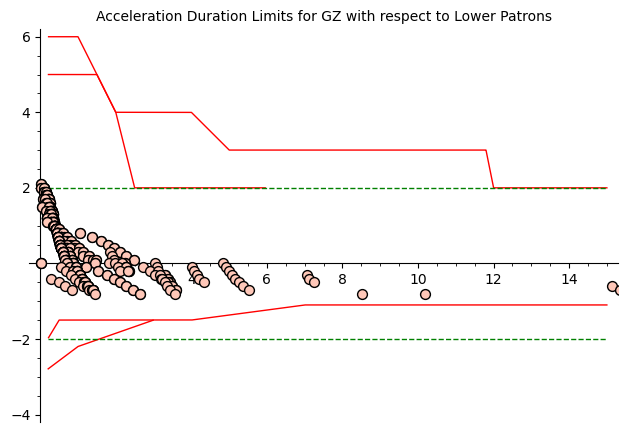

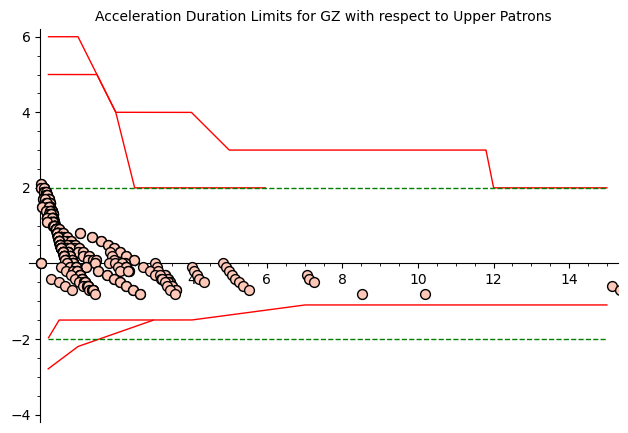

In [15]:
topGz = piecewise([([0.2,1], 6), ((1,2), 8-(2*x)), ([2,4], 4), ((4,5), 8-x), ([5,11.8], 3), ((11.8,12), 62-(5*x)), ([12,40], 2)]);
topGzEXT = piecewise([([0.2,1.5], 5), ((1.5,2), 8-(2*x)), ([2,2.5], 12-(4*x)), ((2.5,6), 2)]);
bottomGz = piecewise([([0.2,0.5], (-14/6)+(5*x/3)), ((0.5,4), -1.5), ([4,7], (-61/30)+(4*x/30)), ((7,40), -1.1)]);
bottomGzEXT = piecewise([([0.2,1], (-2.95)+(6*x/8)), ((1,3), (-51/20)+(7*x/20))]);
REC_Req = 2;
zLims = plot(topGz, [0, 15], rgbcolor = "red") + plot(topGzEXT, [0, 6], rgbcolor = "red") + plot(bottomGz, [0,15], rgbcolor = "red") + plot(bottomGzEXT, (0, 3), rgbcolor = "red") + plot(REC_Req, [0.2,15], linestyle = "dashed", rgbcolor = "green") + plot(-REC_Req, [0.2,15], linestyle = "dashed", rgbcolor = "green");

zdots_lower = scatter_plot([(time, acc) for acc, time in ztable_lower])
show(zLims + zdots_lower, title="Acceleration Duration Limits for GZ with respect to Lower Patrons", aspect_ratio = '1', xmin=0, xmax=15, ymin=-4, ymax=6);

zdots_upper = scatter_plot([(time, acc) for acc, time in ztable_upper])
show(zLims + zdots_upper, title="Acceleration Duration Limits for GZ with respect to Upper Patrons", aspect_ratio = '1', xmin=0, xmax=15, ymin=-4, ymax=6);

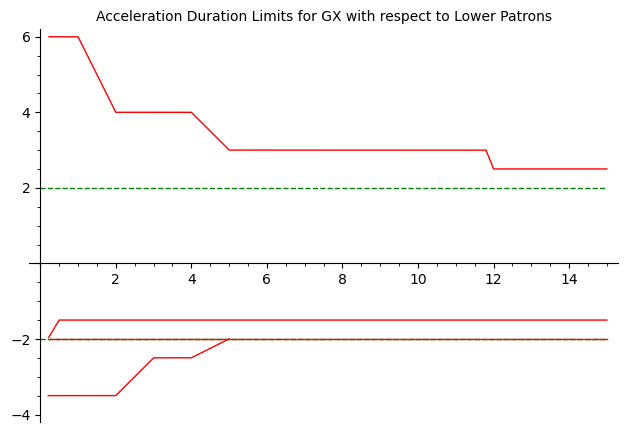

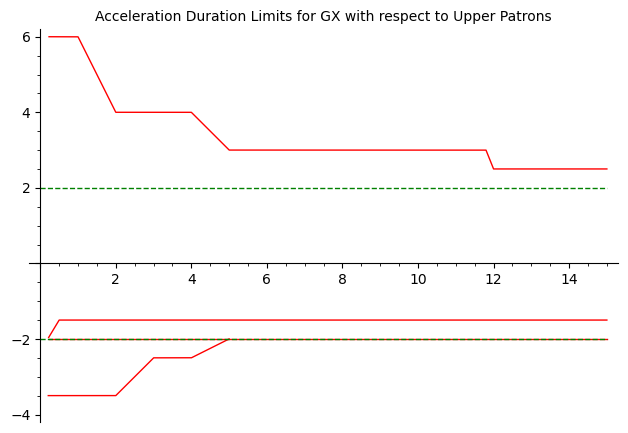

In [16]:
topGx = piecewise([([0.2,1], 6), ((1,2), 8-(2*x)), ([2,4], 4), ((4,5), 8-x), ([5,11.8], 3), ((11.8,12), 32.5-(2.5*x)), ([12,40], 2.5)]);
baseGx =piecewise([((0.2,0.5), (-7/3) + ((5*x/3))), ([0.5, 40], -1.5)]);
bottomGx = piecewise([([0.2, 40], -2)]);
bottomGxEXT = piecewise([([0.2, 2], -3.5), ((2, 3), (x-2)-3.5), ([3, 4], -2.5),((4, 5), -4.5 + (0.5*x)), ([5, 40], -2)]);
REC_Req = 2;
xLims = plot(topGx, [0, 15], rgbcolor = "red") + plot(baseGx, [0, 15], rgbcolor = "red") + plot(bottomGx, [0, 15], rgbcolor = "red") + plot(bottomGxEXT, [0, 5], rgbcolor = "red") + plot(REC_Req, [0,15], linestyle = "dashed", rgbcolor = "green") + plot(-REC_Req, [0,15], linestyle = "dashed", rgbcolor = "green");

show(xLims, title="Acceleration Duration Limits for GX with respect to Lower Patrons", aspect_ratio = '1', xmin = 0, xmax = 15, ymin = -4, ymax = 6); 
show(xLims, title="Acceleration Duration Limits for GX with respect to Upper Patrons", aspect_ratio = '1', xmin = 0, xmax = 15, ymin = -4, ymax = 6); 

In [17]:
# Motor Frequency Table

end_time = sum(2*j for i, j in params)
delta = 0.1^(-1)
freq = []
for dt in range(0, int(delta*end_time)):
    freq.append((dt/delta, n(frequency.subs(x==dt/delta), 3)))
print(max(freq, key=lambda x: x[1]))
# print(freq)

(16.9000000000000, 1.2)


In [18]:
# Motor Chirp Table

end_time = sum(2*j for i, j in params)
delta = 0.1^(-1)
freq_dot = []
for dt in range(0, int(delta*end_time)):
    freq_dot.append((dt/delta, n(frequency_dot.subs(x==dt/delta), 3)))
print(max(freq_dot, key=lambda x: x[1]))
# print(freq_dot)

(39.7000000000000, 1.2)


In [19]:
zmax_l = max(zacc_lower, key=lambda x: x[1])
zmax_u = max(zacc_upper, key=lambda x: x[1])
ymax_l = max(yacc_lower, key=lambda x: x[1])
ymax_u = max(yacc_upper, key=lambda x: x[1])
print(zmax_l)
print(zmax_u)
print(ymax_l)
print(ymax_u)

(21.9400000000000, 2.10670155197555)
(21.9400000000000, 2.10670155197555)
(39.1200000000000, 1.07382604835640)
(39.1200000000000, 1.07382604835640)


In [20]:
zmin_l = min(zacc_lower, key=lambda x: x[1])
zmin_u = min(zacc_upper, key=lambda x: x[1])
ymin_l = min(yacc_lower, key=lambda x: x[1])
ymin_u = min(yacc_upper, key=lambda x: x[1])
print(zmin_l)
print(zmin_u)
print(ymin_l)
print(ymin_u)

(24.3900000000000, -0.877084866130443)
(24.3900000000000, -0.877084866130443)
(20.0000000000000, -1.07206009921720)
(20.0000000000000, -1.07206009921720)
